Klasse mapping:
BlueNoise -> 0
BrownNoise -> 1
Clean -> 2
PinkNoise -> 3
VioletNoise -> 4
WhiteNoise -> 5

Validation Accuracy: 0.9444444444444444

Classification Report (Validation):
              precision    recall  f1-score   support

   BlueNoise       0.93      0.93      0.93        69
  BrownNoise       0.89      0.96      0.92        69
       Clean       0.94      0.90      0.92        69
   PinkNoise       0.99      1.00      0.99        69
 VioletNoise       0.94      0.94      0.94        69
  WhiteNoise       0.98      0.94      0.96        69

    accuracy                           0.94       414
   macro avg       0.95      0.94      0.94       414
weighted avg       0.95      0.94      0.94       414


Confusion Matrix (Validation):
[[64  0  0  0  4  1]
 [ 0 66  3  0  0  0]
 [ 0  7 62  0  0  0]
 [ 0  0  0 69  0  0]
 [ 2  1  1  0 65  0]
 [ 3  0  0  1  0 65]]

Unikke targets i test: [0 1 2 3 4 5]
Antal prøver pr. klasse: [100 100 100 100 100 100]

Test Accuracy: 0.9466666

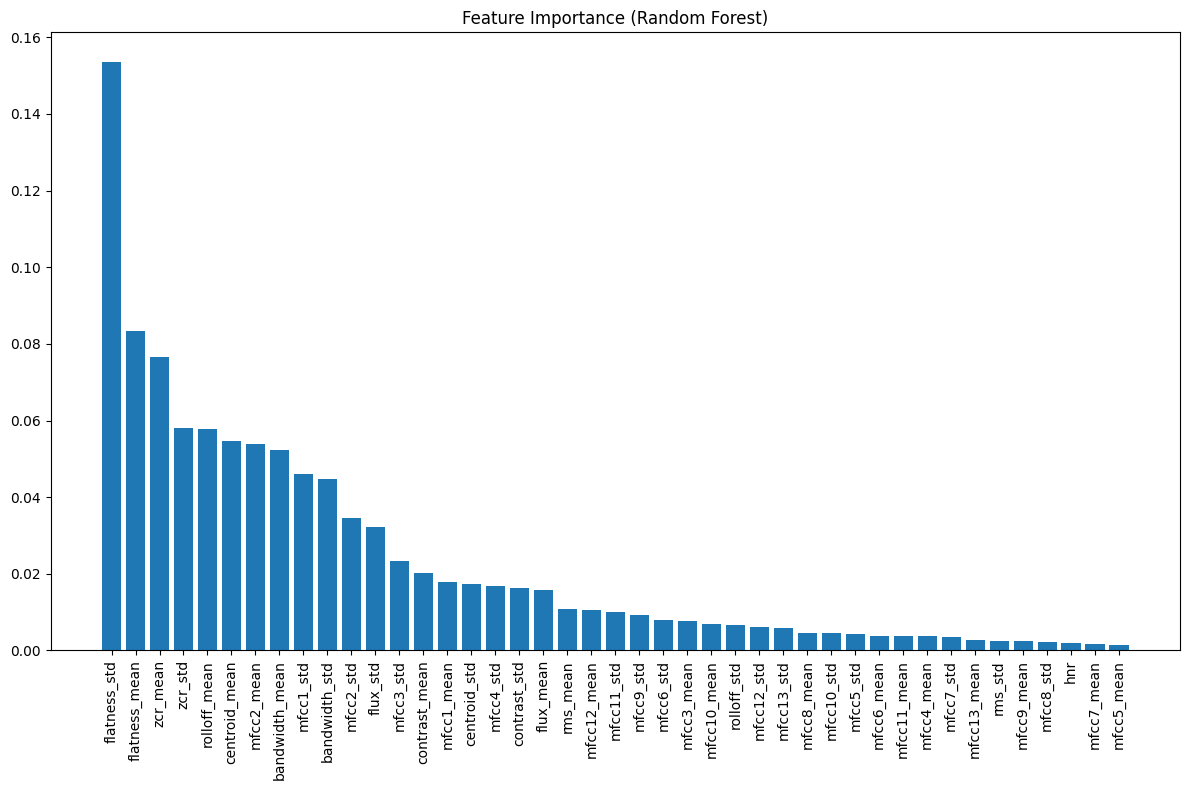


Top 15 vigtigste features:
flatness_std: 0.1536
flatness_mean: 0.0835
zcr_mean: 0.0765
zcr_std: 0.0580
rolloff_mean: 0.0577
centroid_mean: 0.0546
mfcc2_mean: 0.0538
bandwidth_mean: 0.0523
mfcc1_std: 0.0460
bandwidth_std: 0.0447
mfcc2_std: 0.0346
flux_std: 0.0321
mfcc3_std: 0.0232
contrast_mean: 0.0203
mfcc1_mean: 0.0179


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

# ----------------------------
# 1. LOAD TRAINING DATA
# ----------------------------
train_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/TrainingData.csv"
df_train = pd.read_csv(train_path)

# Fjern irrelevant features fra TRAINING
irrelevant_cols = ["filnavn", "beta", "snr_db"]
for col in irrelevant_cols:
    if col in df_train.columns:
        df_train = df_train.drop(columns=[col])

# ----------------------------
# 2. FEATURES & TARGET
# ----------------------------
X = df_train.drop(columns=["target"])
y = df_train["target"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Klasse mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} -> {i}")

# ----------------------------
# 3. TRAIN / VALIDATION SPLIT
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ----------------------------
# 4. RANDOM FOREST MODEL
# ----------------------------
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ----------------------------
# 5. VALIDATION EVALUATION
# ----------------------------
y_val_pred = model.predict(X_val)

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))

# ----------------------------
# 6. LOAD TEST DATA
# ----------------------------
test_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/ValidationData.csv"
df_test = pd.read_csv(test_path)

# Fjern kun filnavn fra TEST (behold beta og snr til error analysis)
if "filnavn" in df_test.columns:
    df_test = df_test.drop(columns=["filnavn"])

# Features til modellen (fjern beta og snr)
X_test = df_test.drop(columns=["target", "beta", "snr_db"], errors="ignore")

# True labels
y_test_true = label_encoder.transform(df_test["target"])

print("\nUnikke targets i test:", np.unique(y_test_true))
print("Antal prøver pr. klasse:", np.bincount(y_test_true))

# ----------------------------
# 7. TEST PREDICTION
# ----------------------------
y_test_pred = model.predict(X_test)

# Evaluer
print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))

# ----------------------------
# 8. FEATURE IMPORTANCE
# ----------------------------
importances = model.feature_importances_
feature_names = X.columns

# Sorter features efter importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

print("\nTop 15 vigtigste features:")
for i in indices[:15]:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

/var/folders/8p/bqxd9lrn4yb0rk196_xwgp780000gn/T/ipykernel_54811/225394830.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  snr_error = df_noise.groupby("snr_bin")["correct"].mean()


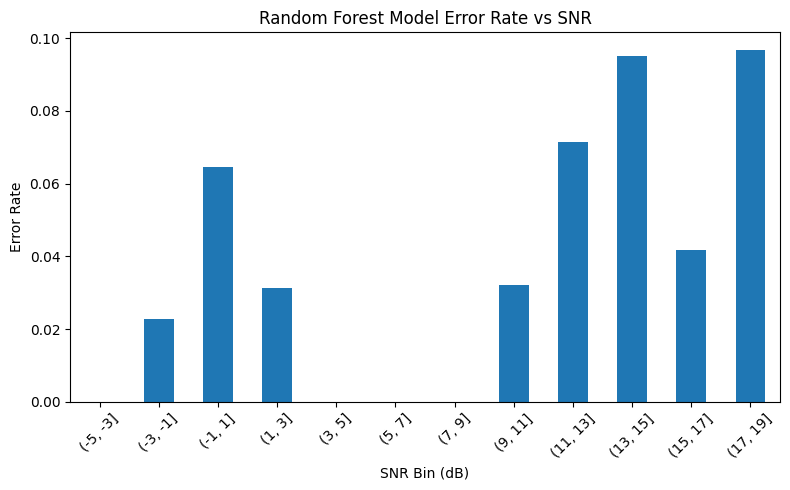

/var/folders/8p/bqxd9lrn4yb0rk196_xwgp780000gn/T/ipykernel_54811/225394830.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  beta_error = df_noise.groupby("beta_bin")["correct"].mean()


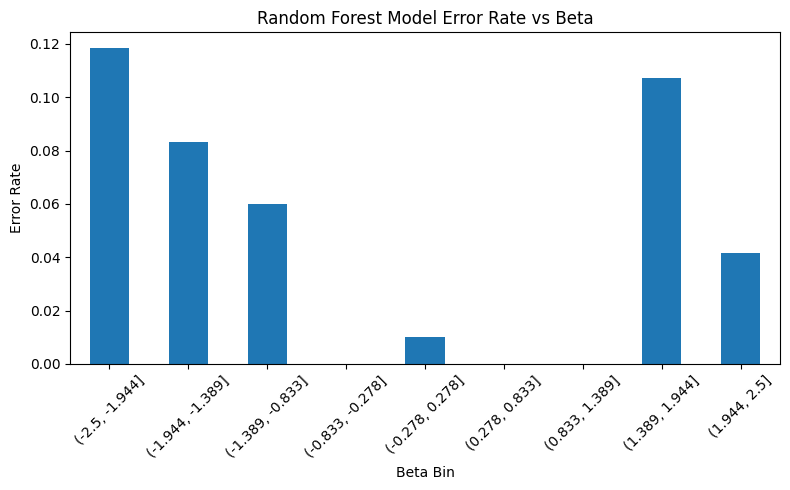


Test Accuracy: 0.9466666666666667

Classification Report (Test):
              precision    recall  f1-score   support

   BlueNoise       0.91      0.94      0.93       100
  BrownNoise       0.93      0.94      0.94       100
       Clean       0.90      0.92      0.91       100
   PinkNoise       1.00      1.00      1.00       100
 VioletNoise       0.95      0.89      0.92       100
  WhiteNoise       0.99      0.99      0.99       100

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600


Confusion Matrix (Test):
[[ 94   0   0   0   5   1]
 [  0  94   6   0   0   0]
 [  1   7  92   0   0   0]
 [  0   0   0 100   0   0]
 [  7   0   4   0  89   0]
 [  1   0   0   0   0  99]]

Eksempler på fejl:
     true_label   pred_label  beta  snr_db
1     BlueNoise  VioletNoise -0.90   11.18
3     BlueNoise  VioletNoise -0.90   19.65
48    BlueNoise   WhiteNoise -1.00   13.48
70    Blue

In [4]:
# ----------------------------
# 8. ERROR ANALYSIS (SNR & BETA)
# ----------------------------

# gem predictions i dataframe
df_analysis = df_test.copy()
df_analysis["y_true"] = y_test_true
df_analysis["y_pred"] = y_test_pred
df_analysis["correct"] = df_analysis["y_true"] == df_analysis["y_pred"]

# behold kun støj (Clean har NaN)
df_noise = df_analysis.dropna(subset=["snr_db", "beta"]).copy()
# fejlrate pr SNR
snr_bins = np.arange(-5, 21, 2)
df_noise["snr_bin"] = pd.cut(df_noise["snr_db"], bins=snr_bins)

snr_error = df_noise.groupby("snr_bin")["correct"].mean()
snr_error = 1 - snr_error

plt.figure(figsize=(8,5))
snr_error.plot(kind="bar")
plt.title("Random Forest Model Error Rate vs SNR")
plt.ylabel("Error Rate")
plt.xlabel("SNR Bin (dB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# fejlrate pr beta
beta_bins = np.linspace(-2.5, 2.5, 10)
df_noise["beta_bin"] = pd.cut(df_noise["beta"], bins=beta_bins)

beta_error = df_noise.groupby("beta_bin")["correct"].mean()
beta_error = 1 - beta_error

plt.figure(figsize=(8,5))
beta_error.plot(kind="bar")
plt.title("Random Forest Model Error Rate vs Beta")
plt.ylabel("Error Rate")
plt.xlabel("Beta Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Lav prediction
y_test_pred = model.predict(X_test)

# Evaluer
print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))


# ----------------------------
# ERROR ANALYSIS
# ----------------------------

df_analysis = df_test.copy()

df_analysis["y_true"] = y_test_true
df_analysis["y_pred"] = y_test_pred
df_analysis["correct"] = df_analysis["y_true"] == df_analysis["y_pred"]

df_analysis["true_label"] = label_encoder.inverse_transform(df_analysis["y_true"])
df_analysis["pred_label"] = label_encoder.inverse_transform(df_analysis["y_pred"])

errors = df_analysis[df_analysis["correct"] == False]

print("\nEksempler på fejl:")
print(errors[["true_label","pred_label","beta","snr_db"]].head(20))